/var/folders/sy/5gqwcnjj7qb00l9k8zqwylmh0000gn/T/ipykernel_99273/2562707532.py:101: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
/var/folders/sy/5gqwcnjj7qb00l9k8zqwylmh0000gn/T/ipykernel_99273/2562707532.py:107: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(


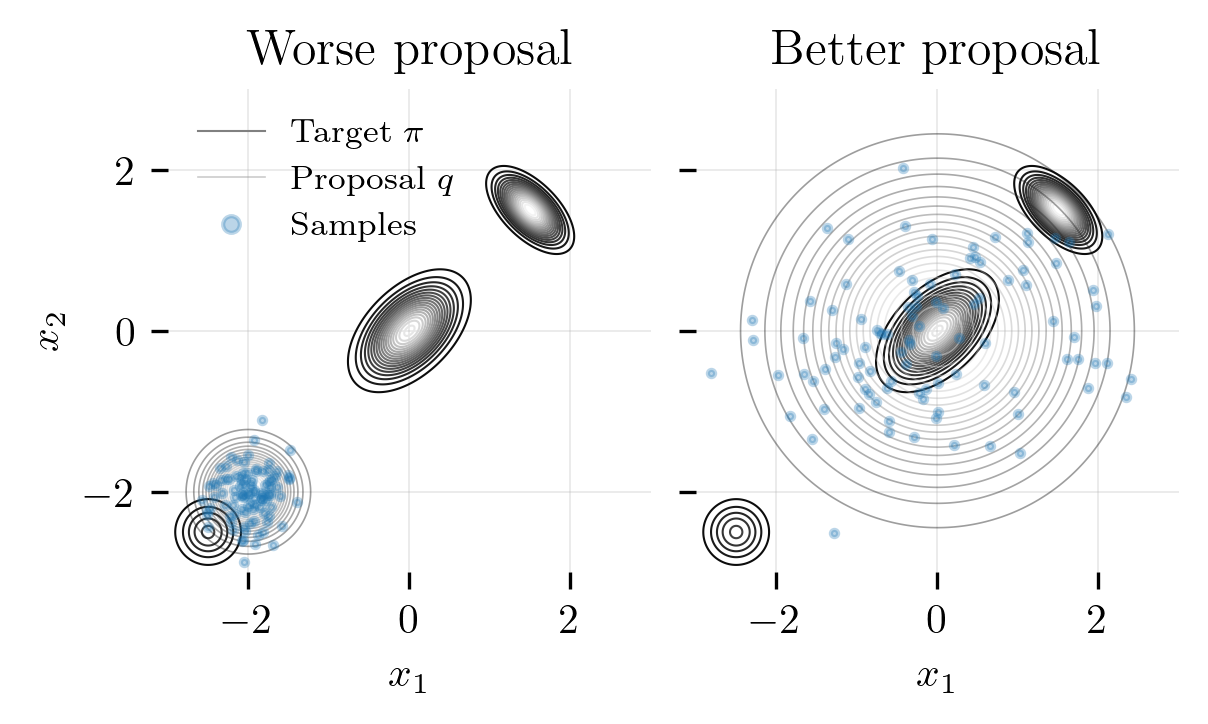

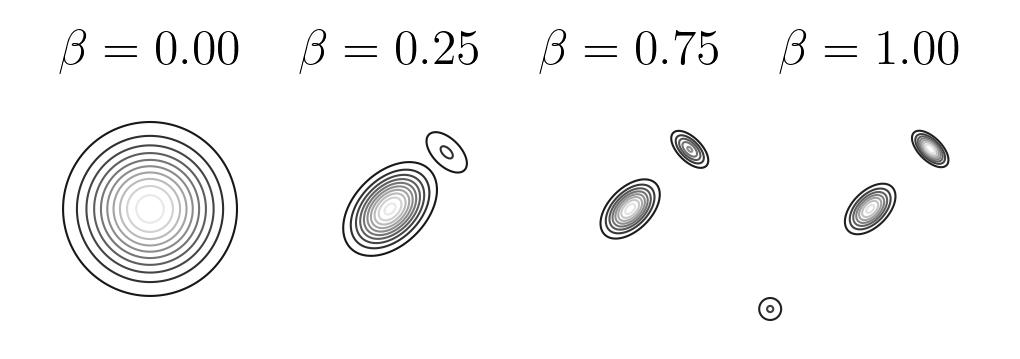

In [ ]:
#!/usr/bin/env python
from __future__ import annotations

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal

# ------------------------------------------------------------------
# matplotlib / latex setup  (unchanged)
# ------------------------------------------------------------------
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
plt.rc("text.latex", preamble=r"\usepackage{amsfonts}\usepackage{amsmath}")

savepath = Path(
    "/Users/shreyaspadhy/Documents/Obsidian Vault/phd-thesis/Chapter2/Figs/"
)


def clean_axis(ax):
    """Remove the top/right spines and set outward ticks."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(direction="out", length=4, width=0.8)


# -----------------------------------------------------------------------------
#  Distributions
# -----------------------------------------------------------------------------


def f_T(x: np.ndarray) -> np.ndarray:
    """Target density: a 3‑component Gaussian mixture."""
    means = [np.array([0.0, 0.0]), np.array([1.5, 1.5]), np.array([-2.5, -2.5])]
    covs = [
        np.array([[0.1, 0.05], [0.05, 0.1]]),
        np.array([[0.05, -0.03], [-0.03, 0.05]]),
        np.array([[0.05, 0.0], [0.0, 0.05]]),
    ]
    weights = [0.6, 0.3, 0.1]

    pdf = np.zeros(x.shape[0])
    for w, m, c in zip(weights, means, covs):
        pdf += w * multivariate_normal(m, c).pdf(x)
    return pdf


def f_0(x: np.ndarray) -> np.ndarray:
    """Standard normal reference density."""
    return multivariate_normal(np.zeros(2), np.eye(2)).pdf(x)


# -----------------------------------------------------------------------------
#  Grid for contour plots
# -----------------------------------------------------------------------------

gridx, gridy = np.mgrid[-3:3:0.01, -3:3:0.01]
grid = np.dstack((gridx, gridy))

pdf_T = f_T(grid.reshape(-1, 2)).reshape(grid.shape[:2])

N = 100
q_1 = multivariate_normal(np.array([-2.0, -2.0]), 0.1 * np.eye(2))
q_2 = multivariate_normal(np.array([0.0, 0.0]), np.eye(2))

samples_1 = q_1.rvs(N)
samples_2 = q_2.rvs(N)

# For plotting proposal contours
q_pdf_1 = q_1.pdf(grid.reshape(-1, 2)).reshape(grid.shape[:2])
q_pdf_2 = q_2.pdf(grid.reshape(-1, 2)).reshape(grid.shape[:2])

# -----------------------------------------------------------------------------
#  Figure 2 – IS proposals vs target
# -----------------------------------------------------------------------------

fig2, axs = plt.subplots(
    1,
    2,
    figsize=(4.13, 1.5),
    dpi=300,
    sharex=True,
    sharey=True,
)
fig2.subplots_adjust(wspace=0.0)
import seaborn as sns

sns_blue = sns.color_palette("tab10")[0]

for ax, qsamp, qpdf, title in zip(
    axs,
    (samples_1, samples_2),
    (q_pdf_1, q_pdf_2),
    ("Worse proposal", "Better proposal"),
):
    ax.contour(
        gridx, gridy, pdf_T, levels=20, cmap="grey", linewidths=0.5, label="Target"
    )
    ax.scatter(
        qsamp[:, 0], qsamp[:, 1], s=3, alpha=0.3, marker="o", color=sns_blue, zorder=5
    )
    ax.contour(
        gridx,
        gridy,
        qpdf,
        levels=20,
        cmap="grey",
        alpha=0.4,
        linewidths=0.4,
        label="Proposal",
    )
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(True, which="major", linewidth=0.4, alpha=0.3)

for ax in axs:
    ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel=r"$x_1$")
    clean_axis(ax)

axs[0].set(ylabel=r"$x_2$")
# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())

# Create custom legend handles and labels
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="grey", lw=0.5, label=r"Target $\pi$"),
    Line2D([0], [0], color="grey", alpha=0.4, lw=0.4, label=r"Proposal $q$"),
    Line2D(
        [0],
        [0],
        marker="o",
        color=sns_blue,
        markersize=4,
        linestyle="None",
        alpha=0.3,
        label="Samples",
    ),
]
# Add legend to the first subplot
axs[0].legend(handles=legend_elements, fontsize=8, loc="upper left", frameon=False)
fig2.tight_layout()

plt.savefig(
    Path(savepath) / "Vector" / "is_worse_vs_better.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.savefig(
    Path(savepath) / "Raster" / "is_worse_vs_better.png",
    format="png",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.show()

betas_plot = [0.0, 0.25, 0.75, 1.0]

fig3, axs3 = plt.subplots(1, 4, figsize=(4.13, 2.07), dpi=300, sharex=True, sharey=True)
fig3.subplots_adjust(wspace=0.0)


def f_t(x: np.ndarray, beta: float) -> np.ndarray:
    """Annealed intermediate density $f_t(x;\beta)$."""
    return np.power(f_0(x), 1.0 - beta) * np.power(f_T(x), beta)


for ax, beta in zip(axs3, betas_plot):
    pdf_beta = f_t(grid.reshape(-1, 2), beta).reshape(grid.shape[:2])
    ax.contour(gridx, gridy, pdf_beta, levels=10, linewidths=0.5, cmap="grey")
    ax.set(
        aspect="equal",
        title=rf"$\beta={beta:.2f}$",
        xlim=(-3, 3),
        ylim=(-3, 3),
        # xlabel=r"$x_1$",
        # ylabel=r"$x_2$",
    )
    # Remove x and y axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True, which="major", linewidth=0.4, alpha=0.3)
    # ax.xaxis.set_minor_locator(AutoMinorLocator())
    # ax.yaxis.set_minor_locator(AutoMinorLocator())
    clean_axis(ax)

# fig3.tight_layout()
# fig2.savefig("is_worse_vs_better.pdf", bbox_inches="tight")
# plt.close(fig2)

# print("Figures saved to:")
# for f in ("contour_target.pdf", "is_worse_vs_better.pdf"):
#     print(f"  • {Path(f).resolve()}")

/var/folders/sy/5gqwcnjj7qb00l9k8zqwylmh0000gn/T/ipykernel_60715/54196810.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


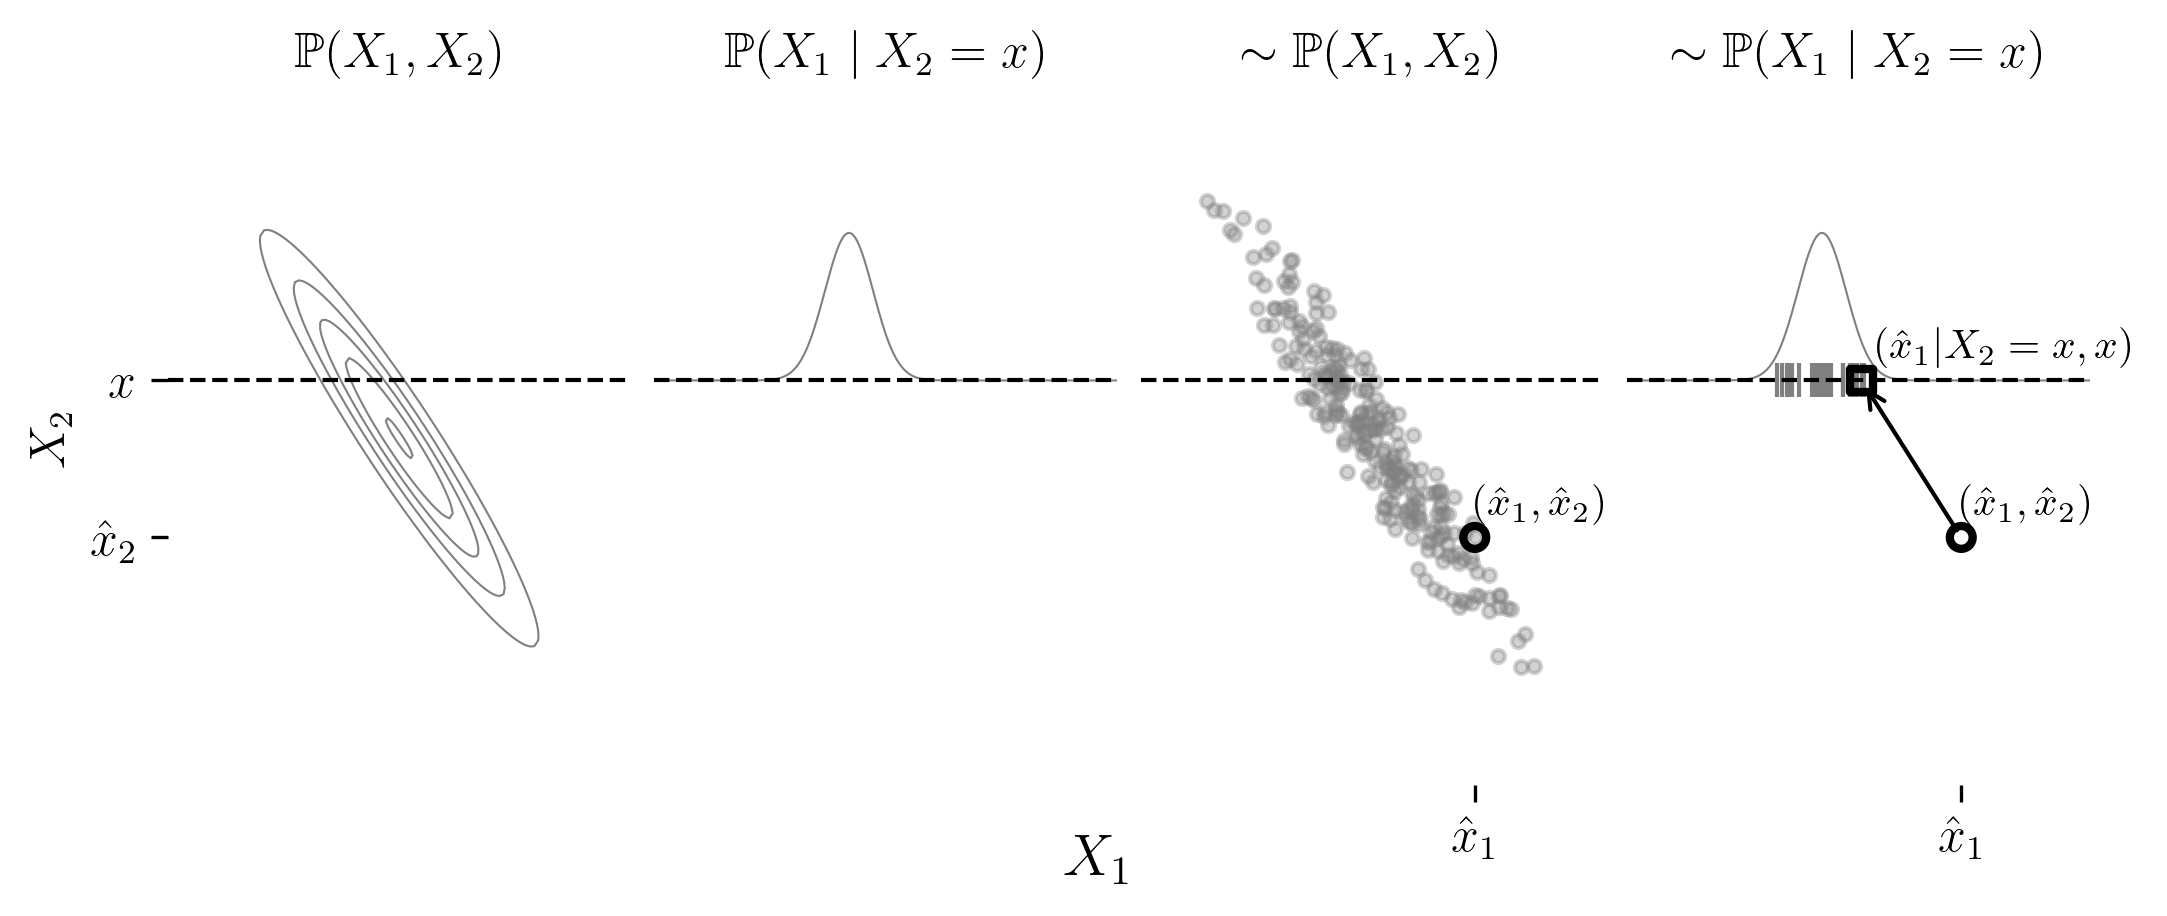

In [106]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal, norm

# ------------------------------------------------------------------
#  Matplotlib / LaTeX setup  (unchanged)
# ------------------------------------------------------------------
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
plt.rc("text.latex", preamble=r"\usepackage{amsfonts}\usepackage{amsmath}")

savepath = Path(
    "/Users/shreyaspadhy/Documents/Obsidian Vault/phd-thesis/Chapter2/Figs/"
)


# ── global set-up ─────────────────────────────────────────────────────────
μ = np.zeros(2)
Σ = np.array([[1.0, -0.95], [-0.95, 1.0]])
β = 0.5  # b-value we condition on

σ_aa, σ_bb = Σ[0, 0], Σ[1, 1]
σ_ab = Σ[0, 1]
k = σ_ab / σ_bb  # Σ_ab Σ_bb^{-1}

μ_c = μ[0] + k * (β - μ[1])  # E[a | b=β]
σ_c2 = σ_aa - σ_ab**2 / σ_bb
σ_c = np.sqrt(σ_c2)

# ── canvas ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 4, figsize=(8.27, 3), gridspec_kw=dict(wspace=0.05), dpi=300)

# ── panel 1 : joint PDF (contours) ───────────────────────────────────────
x, y = np.mgrid[-3:3:0.05, -3:3:0.05]
pos = np.dstack((x, y))
pdf = multivariate_normal(μ, Σ).pdf(pos)

ax[0].contour(x, y, pdf, levels=5, linewidths=0.5, colors="grey")
# ax[0].plot(*μ, marker='o', color='steelblue')
ax[0].axhline(β, color="k", lw=1, ls="--")
ax[0].set_xlim(-3, 3)
ax[0].set_ylim(-3, 3)

# ── panel 2 : conditional PDF along b = β ────────────────────────────────
xs = np.linspace(-3, 3, 401)
pdf_cond = norm.pdf(xs, loc=μ_c, scale=σ_c)

ax[1].plot(xs, β + pdf_cond, color="grey", lw=0.5)  # density “floats” on b=β
ax[1].axhline(β, color="k", lw=1, ls="--")
ax[1].set_xlim(-3, 3)
ax[1].set_ylim(-3, 3)
# ax[1].axvline(μ_c, ls='--', color='k')

# ── draw raw samples ─────────────────────────────────────────────────────
rng = np.random.default_rng(2024)
# Generate more samples initially to filter
samples_all = rng.multivariate_normal(μ, Σ, size=1000)
# Calculate pdf values for each sample
pdf_values = multivariate_normal(μ, Σ).pdf(samples_all)
# Filter samples with pdf > 0.4
mask = pdf_values > 0.05
samples = samples_all[mask]
# If we need exactly 200 samples, we can take the first 200 or resample
if len(samples) > 250:
    samples = samples[:250]
a_s, b_s = samples.T
# Make sure idx_star is within bounds
idx_star = min(6, len(samples) - 1)
a_star, b_star = samples[idx_star]

# ── panel 3 : raw samples + highlight + Matheron arrow ───────────────────
ax[2].scatter(a_s, b_s, s=10, alpha=0.35, color="grey")
ax[2].scatter(a_star, b_star, s=30, marker="o", facecolor="none", edgecolor="k", lw=2)
ax[2].axhline(β, color="k", lw=1, ls="--")
ax[2].set_xlim(-3, 3)
ax[2].set_ylim(-3, 3)
a_prime = a_star + k * (β - b_star)  # Matheron move
# ax[2].annotate('', xy=(a_prime, β), xytext=(a_star, b_star),
#                arrowprops=dict(arrowstyle='->', lw=2))

# ── panel 4 : conditional ticks + overlaid PDF ───────────────────────────
a_cond = a_s + k * (β - b_s)
ax[3].plot(xs, β + pdf_cond, color="grey", lw=0.5)  # dashed PDF
# Subsample to 30 points for cleaner visualization
subsample_indices = np.linspace(0, len(a_cond) - 1, 30, dtype=int)
ax[3].plot(
    a_cond[subsample_indices],
    β * np.ones_like(a_cond[subsample_indices]),
    "|",
    ms=8,
    color="grey",
    lw=0.5,
)
ax[3].scatter(a_star, b_star, s=30, marker="o", facecolor="none", edgecolor="k", lw=2)
ax[3].scatter(
    a_prime, β, s=30, facecolor="none", edgecolor="k", lw=2, zorder=5, marker="s"
)
ax[3].axhline(β, color="k", lw=1, ls="--")

# Draw a dotted arrow from (a_star, b_star) to (a_prime, β)
ax[3].annotate(
    "",
    xy=(a_prime, β),  # arrow tip (destination)
    xytext=(a_star, b_star),  # arrow base (start)
    arrowprops=dict(
        arrowstyle="->",
        #    linestyle='dotted',
        lw=1,
        color="k",
    ),
)

# Label the points in panel 3
ax[3].annotate(
    "$(\hat{x}_1, \hat{x}_2)$",
    xy=(a_star, b_star),
    xytext=(a_star, b_star + 0.2),
    fontsize=10,
)

# Label the points in panel 3
ax[2].annotate(
    "$(\hat{x}_1, \hat{x}_2)$",
    xy=(a_star, b_star),
    xytext=(a_star, b_star + 0.2),
    fontsize=10,
)

# Label the conditional point in panel 3
ax[3].annotate(
    "$(\hat{x}_1 | X_2 = x, x)$",
    xy=(a_prime, β),
    xytext=(a_prime + 0.2, β + 0.2),
    fontsize=10,
)

# Label the horizontal line in all subplots as X_2 = x
# for i in range(1):
#     ax[i].annotate('$X_2 = x$',
#                    xy=(-2.8, β),
#                    xytext=(-2.8, β+0.2),
#                    fontsize=10)

# Label the horizontal line in all subplots as x on the y-axis


# Add a single global x-axis label for all subplots
fig.text(0.5, 0.01, "$X_1$", ha="center", fontsize=14)

# Add y-axis label to the first subplot
ax[0].set_ylabel("$X_2$", fontsize=12)

# Create a global legend for all subplots
# First, create empty handles and labels for the legend items
from matplotlib.lines import Line2D

# legend_elements = [
#     Line2D([0], [0], color='grey', lw=0.5, label=r'Joint distribution $\mathbb{P}(X_1, X_2)$'),
#     Line2D([0], [0], color='grey', lw=1, ls='--', label=r'Conditional distribution $\mathbb{P}(X_1 \mid X_2 = x)$'),
#     Line2D([0], [0], color='grey', alpha=0.35, label=r'Samples from $\mathbb{P}(X_1, X_2)$'),
# ]

# legend_elements2 = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=6, label=r'$(x_1, x_2) \sim \mathbb{P}(X_1, X_2)$'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markeredgecolor='b', markersize=6, label=r'Sample from $\mathbb{P}(X_1 \mid X_2 = x)$'),
#     Line2D([0], [0], marker='s', color='w', markerfacecolor='none', markeredgecolor='b', markersize=6, label=r'Conditional sample at $X_2 = x$'),
#     Patch(facecolor='none', edgecolor='r', hatch='', label=r"Matheron's update")
# ]

# # Add the legend to the figure, outside of any specific subplot
# fig.legend(handles=legend_elements + legend_elements2, loc='upper left', bbox_to_anchor=(0.05, 0.95), frameon=False, fontsize=10, ncol=2)


# Add titles to the subplots
ax[0].set_title(r"$\mathbb{P}(X_1, X_2)$", fontsize=12)
ax[1].set_title(r"$\mathbb{P}(X_1 \mid X_2 = x)$", fontsize=12)

ax[2].set_title(r"$\sim \mathbb{P}(X_1, X_2)$", fontsize=12)

ax[3].set_title(r"$\sim \mathbb{P}(X_1 \mid X_2 = x)$", fontsize=12)

ax[3].set_xlim(-3, 3)
ax[3].set_ylim(-3, 3)

# ax[3].axvline(μ_c, ls='--', color='k')

# ── cosmetics : strip every axis frame/tick/label ────────────────────────
for a in ax:
    a.set(xticks=[], yticks=[])
    for spine in a.spines.values():
        spine.set_visible(False)

for i in range(1):
    ax[i].set_yticks([β, b_star])
    ax[i].set_yticklabels(["$x$", "$\\hat{x}_2$"], fontsize=12)
    # Make the tick visible
    ax[i].tick_params(axis="y", which="both", length=4, direction="out")
    # Make the y-axis line visible at the tick location
    ax[i].spines["left"].set_visible(True)
    ax[i].spines["left"].set_bounds(β, β)

# Add axis label and tick for a_star in ax[2]
ax[2].set_xticks([a_star])
ax[2].set_xticklabels(["$\\hat{x}_1$"], fontsize=12)
ax[2].tick_params(axis="x", which="both", length=4, direction="out")
ax[2].spines["bottom"].set_visible(True)
ax[2].spines["bottom"].set_bounds(a_star, a_star)

# Add axis label and tick for a_star in ax[2]
ax[3].set_xticks([a_star])
ax[3].set_xticklabels(["$\\hat{x}_1$"], fontsize=12)
ax[3].tick_params(axis="x", which="both", length=4, direction="out")
ax[3].spines["bottom"].set_visible(True)
ax[3].spines["bottom"].set_bounds(a_star, a_star)


plt.tight_layout()

plt.savefig(
    Path(savepath) / "Vector" / "matherons.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.savefig(
    Path(savepath) / "Raster" / "matherons.png",
    format="png",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.show()